Loan Default Prediction
====

Import libraries
-----

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load your CSV
----

In [4]:
df = pd.read_csv("loan_data.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (9578, 14)


In [5]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


Check the columns
---

In [6]:
print("Columns in the dataset:")
for column in df.columns:
    print(column)

Columns in the dataset:
credit.policy
purpose
int.rate
installment
log.annual.inc
dti
fico
days.with.cr.line
revol.bal
revol.util
inq.last.6mths
delinq.2yrs
pub.rec
not.fully.paid


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


Check the target distribution
----

In [11]:
print(df["not.fully.paid"].value_counts())

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64


In [12]:
print(df["not.fully.paid"].value_counts(normalize=True) * 100)

not.fully.paid
0    83.994571
1    16.005429
Name: proportion, dtype: float64


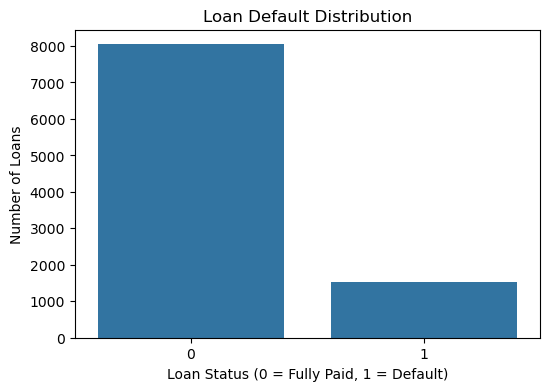

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(x="not.fully.paid", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0 = Fully Paid, 1 = Default)")
plt.ylabel("Number of Loans")

plt.show()

EDA: Histograms
--

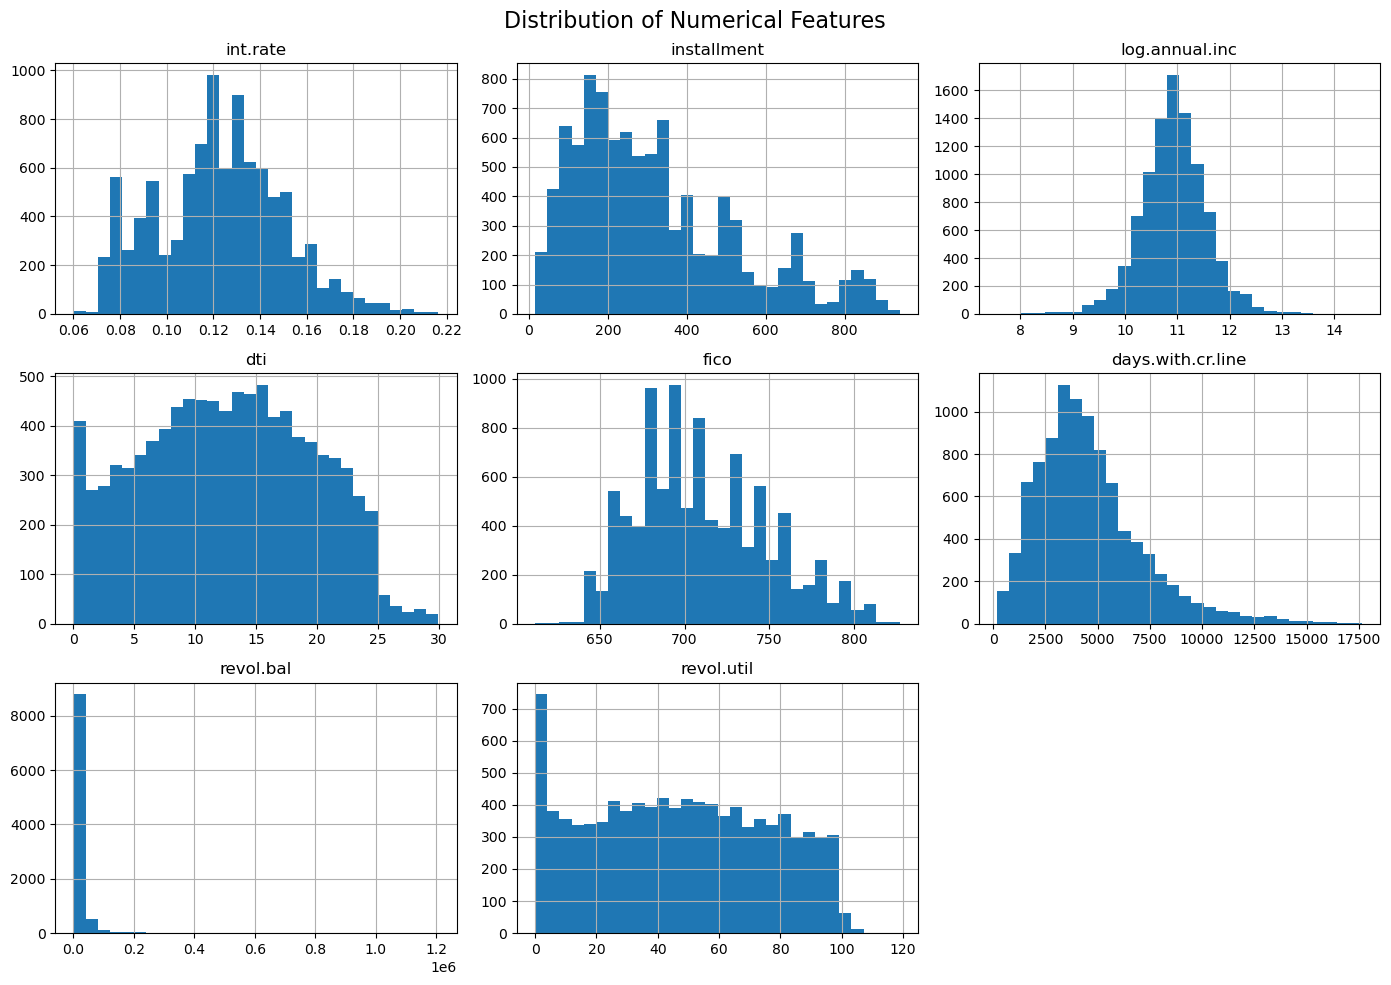

In [14]:
numeric_columns = [
    "int.rate",
    "installment",
    "log.annual.inc",
    "dti",
    "fico",
    "days.with.cr.line",
    "revol.bal",
    "revol.util"
]

df[numeric_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Default rate by loan purpose
---

In [15]:
default_by_purpose = df.groupby("purpose")["not.fully.paid"].mean() * 100

print(default_by_purpose.sort_values(ascending=False))

purpose
small_business        27.786753
educational           20.116618
home_improvement      17.011129
all_other             16.602317
debt_consolidation    15.238817
credit_card           11.568938
major_purchase        11.212815
Name: not.fully.paid, dtype: float64


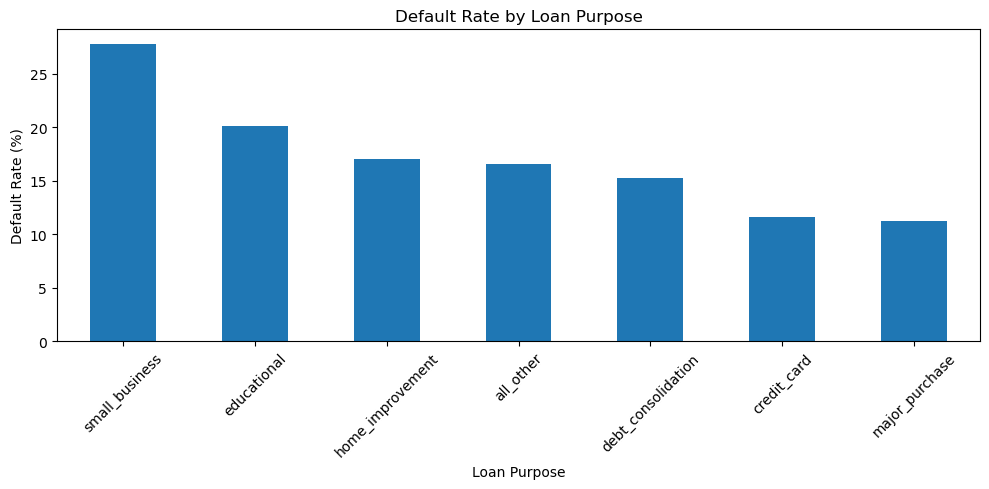

In [16]:
plt.figure(figsize=(10, 5))

default_by_purpose.sort_values(ascending=False).plot(kind="bar")

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Boxplot: Interest Rate vs Default
---

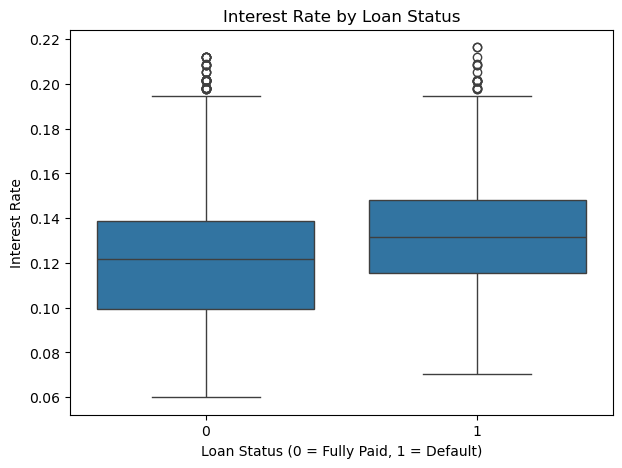

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="not.fully.paid",
    y="int.rate",
    data=df
)

plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status (0 = Fully Paid, 1 = Default)")
plt.ylabel("Interest Rate")

plt.show()

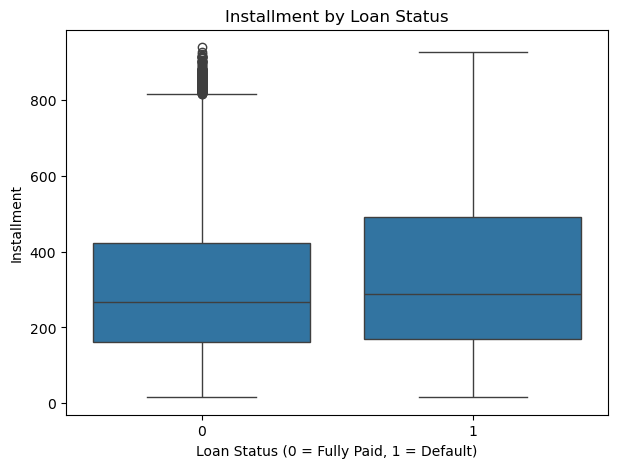

In [18]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="not.fully.paid",
    y="installment",
    data=df
)

plt.title("Installment by Loan Status")
plt.xlabel("Loan Status (0 = Fully Paid, 1 = Default)")
plt.ylabel("Installment")

plt.show()

Correlation Heatmap
---

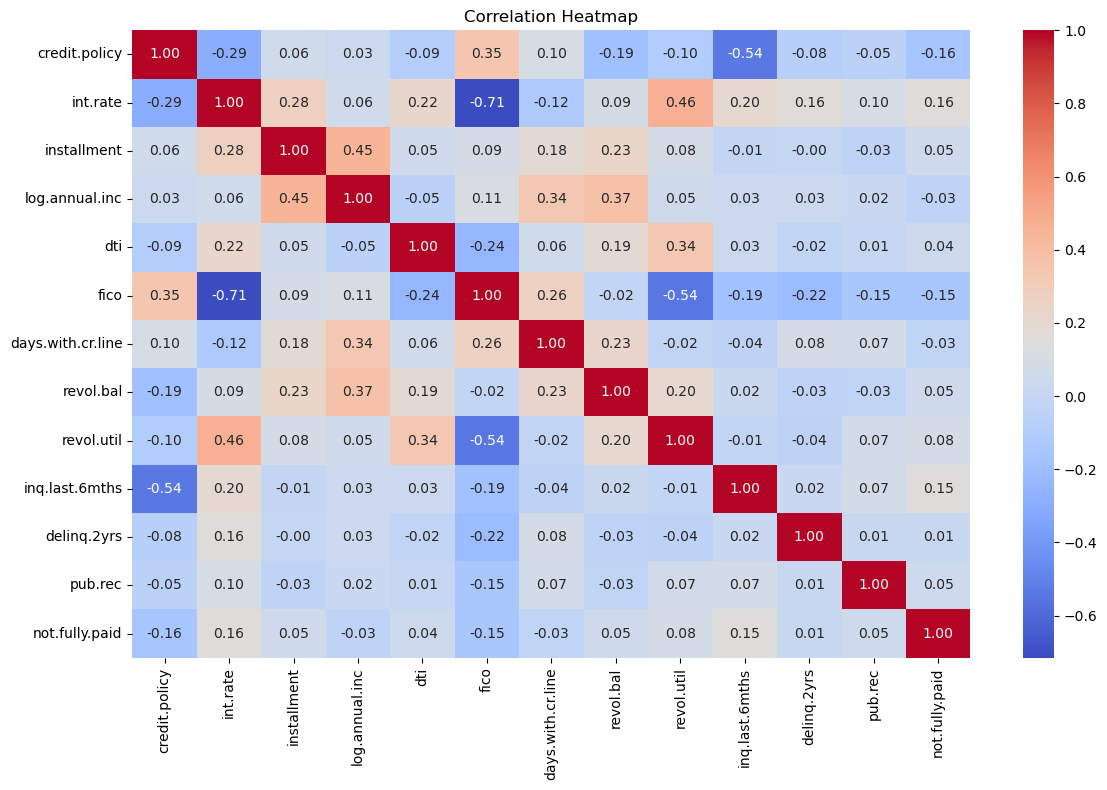

In [19]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [20]:
target_correlation = correlation["not.fully.paid"].sort_values(
    ascending=False
)

print(target_correlation)

not.fully.paid       1.000000
int.rate             0.159552
inq.last.6mths       0.149452
revol.util           0.082088
revol.bal            0.053699
installment          0.049955
pub.rec              0.048634
dti                  0.037362
delinq.2yrs          0.008881
days.with.cr.line   -0.029237
log.annual.inc      -0.033439
fico                -0.149666
credit.policy       -0.158119
Name: not.fully.paid, dtype: float64


Check categorical values
--

In [21]:
print(df["purpose"].value_counts())

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64


Separate Features and Target
---

In [22]:
X = df.drop("not.fully.paid", axis=1)
y = df["not.fully.paid"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9578, 13)
Target shape: (9578,)


Identify numerical and categorical columns
---

In [23]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['purpose']

Numerical features:
['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']


Train/Test Split
--

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7662, 13)
Testing data: (1916, 13)


Preprocessing Pipeline
------

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


 #What above cell is doing
 ---
✅ Missing numerical values → median
✅ Missing categorical values → most frequent
✅ One-hot encoding → purpose
✅ Scaling → StandardScaler

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


Logistic Regression
--

In [28]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [30]:
# Prediction
#------
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions completed!")

Predictions completed!


In [32]:
##Evaluate Logistic Regression
#-----
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.6409
Precision: 0.2401
Recall   : 0.5733
F1 Score : 0.3385
ROC-AUC  : 0.6844


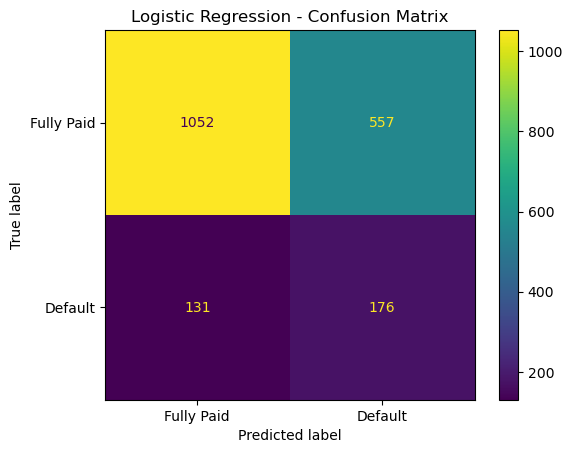

In [34]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fully Paid", "Default"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

---Decision Tree
-----

In [35]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42,
        max_depth=10
    ))
])

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [36]:
#predictions
y_pred_dt = decision_tree_model.predict(X_test)

y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions completed!")

Decision Tree predictions completed!


In [37]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))
print("ROC-AUC  :", round(roc_auc_dt, 4))

Decision Tree Results
--------------------
Accuracy : 0.6394
Precision: 0.21
Recall   : 0.4528
F1 Score : 0.2869
ROC-AUC  : 0.57


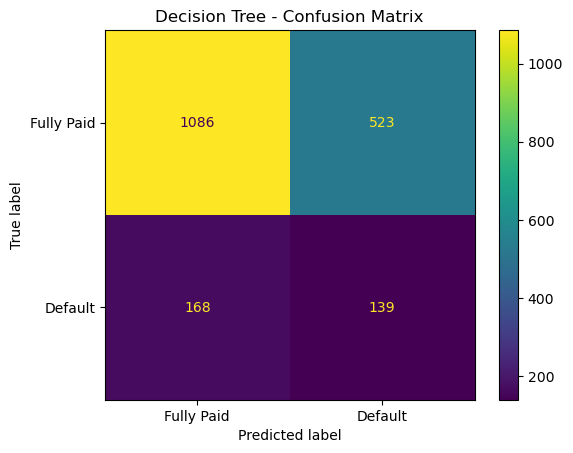

In [38]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Fully Paid", "Default"]
)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

--Random Forest
----

In [39]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [40]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [41]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Results
--------------------
Accuracy : 0.8382
Precision: 0.2
Recall   : 0.0033
F1 Score : 0.0064
ROC-AUC  : 0.6796


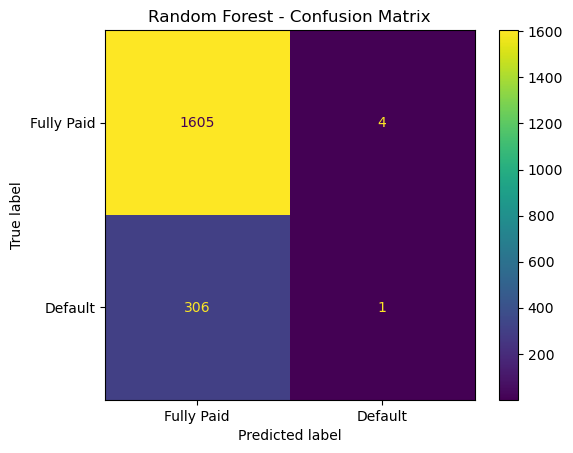

In [42]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Fully Paid", "Default"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

the final comparison table
--

In [43]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],
    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6409,0.2401,0.5733,0.3385,0.6844
1,Decision Tree,0.6394,0.2100,0.4528,0.2869,0.5700
2,Random Forest,0.8382,0.2000,0.0033,0.0064,0.6796


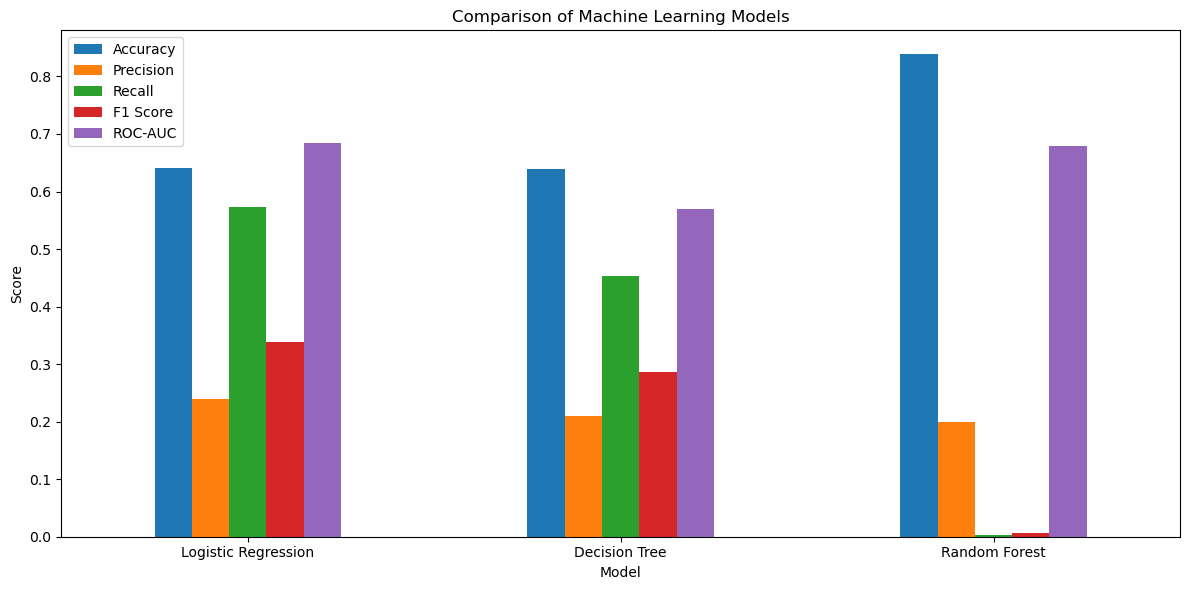

In [44]:
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

Saving our final model
--

In [46]:
import joblib

joblib.dump(logistic_model, "loan_default_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [47]:
import os

print(os.path.exists("loan_default_model.pkl"))

True


In [48]:
loaded_model = joblib.load("loan_default_model.pkl")

test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Test predictions:", test_prediction)

Test predictions: [1 0 0 1 1]


In [1]:
import sklearn
import joblib
import sys

print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)
print("Joblib version:", joblib.__version__)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Scikit-learn version: 1.7.2
Joblib version: 1.5.2


In [2]:
import sys
print(sys.executable)

C:\Users\Mallikarjun\anaconda3\python.exe
